First 5 Rows of Dataset
   Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0            1360             2              1        1981  0.599637   
1            4272             3              3        2016  4.753014   
2            3592             1              2        2016  3.634823   
3             966             1              2        1977  2.730667   
4            4926             2              1        1993  4.699073   

   Garage_Size  Neighborhood_Quality   House_Price  
0            0                     5  2.623829e+05  
1            1                     6  9.852609e+05  
2            0                     9  7.779774e+05  
3            1                     8  2.296989e+05  
4            0                     8  1.041741e+06  

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----

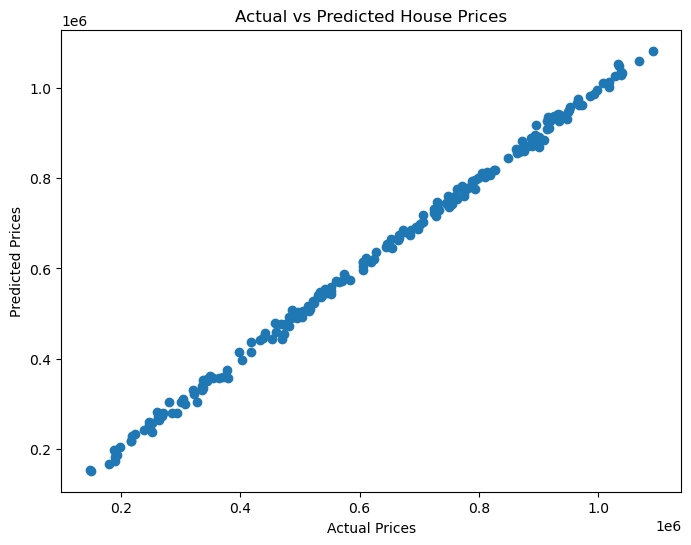


Feature Coefficients
                Feature   Coefficient
0        Square_Footage    199.513245
1          Num_Bedrooms  10225.204424
2         Num_Bathrooms   8208.434778
3            Year_Built    993.537171
4              Lot_Size  14885.384415
5           Garage_Size   5146.148383
6  Neighborhood_Quality    115.068595

Model Intercept
-2010567.420270204
File saved successfully!


In [2]:
# LINEAR REGRESSION PROJECT
# House Price Prediction using Machine Learning

# Step 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 2 - Load Dataset
df = pd.read_csv(r"C:\Users\Admin\Downloads\OBSIP\Triveni_Task 5\Dataset\house_price_regression_dataset.csv")
# Step 3 - Display First 5 Rows
print("First 5 Rows of Dataset")
print(df.head())

# Step 4 - Dataset Information
print("\nDataset Information")
print(df.info())

# Step 5 - Check Missing Values
print("\nMissing Values")
print(df.isnull().sum())

# Step 6 - Statistical Summary
print("\nDataset Summary")
print(df.describe())

# Step 7 - Separate Features and Target Variable
# Replace 'Price' with your target column name if different
# Step 7 - Separate Features and Target Variable

target_column = 'House_Price'   
X = df.drop(target_column, axis=1)
y = df[target_column]

# Step 8 - Convert Categorical Data into Numerical
X = pd.get_dummies(X, drop_first=True)

print("\nFeatures after Encoding")
print(X.head())

# Step 9 - Split Dataset into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining Data Shape")
print(X_train.shape)

print("\nTesting Data Shape")
print(X_test.shape)

# Step 10 - Create Linear Regression Model
model = LinearRegression()

# Step 11 - Train Model
model.fit(X_train, y_train)

print("\nModel Training Completed")

# Step 12 - Predict Test Data
y_pred = model.predict(X_test)

print("\nPredicted Values")
print(y_pred[:10])

# Step 13 - Model Evaluation

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# R2 Score
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("Mean Squared Error :", mse)
print("R2 Score :", r2)

# Step 14 - Compare Actual vs Predicted Values
comparison = pd.DataFrame({
    'Actual Value': y_test.values,
    'Predicted Value': y_pred
})

print("\nActual vs Predicted Values")
print(comparison.head(10))

# Step 15 - Visualization

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

# Step 16 - Regression Coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nFeature Coefficients")
print(coefficients)

# Step 17 - Intercept
print("\nModel Intercept")
print(model.intercept_)
# Save cleaned/processed dataset to a new CSV file

df.to_csv(
    r"C:\Users\Admin\Downloads\OBSIP\Triveni_Task 5\Dataset\house_price_output.csv",
    index=False
)

print("File saved successfully!")